# GCE Model.

This model demonstrates key output from the Galactic Chemical Evolution model.  The first step is to install the necessary packages.

In [1]:
import sys
!{sys.executable} -m pip install --quiet requests matplotlib wnutils

Next, import the necessary packages:

In [2]:
import os, io, requests
import wnutils as wn
import matplotlib.pyplot as plt

## Retrieve model and Solar System data

Retrieve the GCE model.

In [3]:
#!rm -fr gce.h5
#!curl -J -L -o gce.h5.gz https://osf.io/me9cr/download
#!gunzip gce.h5.gz

Load the model into a *wnutils* H5 class instance.

In [4]:
#h5 = wn.h5.H5('gce.h5')
h5 = wn.h5.H5('work/out_new.h5')

Now retrieve the Solar abundances from [OSF](https://osf.io/udvsk/).  The stellar yield data for the current GCE calculations used [Anders and Grevesse (1989)](https://ui.adsabs.harvard.edu/abs/1989GeCoA..53..197A/abstract) data as input, so use those solar data for comparison.

In [5]:
solar_xml = wn.xml.Xml(io.BytesIO(requests.get('https://osf.io/w8ktc/download').content))
solar_data = solar_xml.get_zone_data()
x_solar = solar_data['0']['mass fractions']

# Plot data.

Begin by setting parameter to determine whether to save figures to the local directory.  The default is not to do this.

In [6]:
save_figs = False

Now select the reservoirs.

In [7]:
molecular_cloud = ('molecular cloud', '0', '0')
gas = ('gas', '0', '0')
old_dust = ('old_dust', '0', '0')
snII_dust = ('snII_dust', '0', '0')
snIa_dust = ('snIa_dust', '0', '0')
low_mass_dust = ('low_mass_dust', '0', '0')
nrlee_dust = ('nrlee dust', '0', '0')

Retrieve data from the various reservoirs.

In [8]:
v_props = ['time', 'zone mass', 'metallicity']

props = {}
for component in [molecular_cloud, gas, old_dust, snII_dust, snIa_dust, low_mass_dust, nrlee_dust]:
    props[component] = h5.get_zone_properties_in_groups_as_floats(component, v_props)

Graph the gas fraction.  It should be about 15-20% (shown as the light blue band) today (around a time of 13.5 Gyr).  

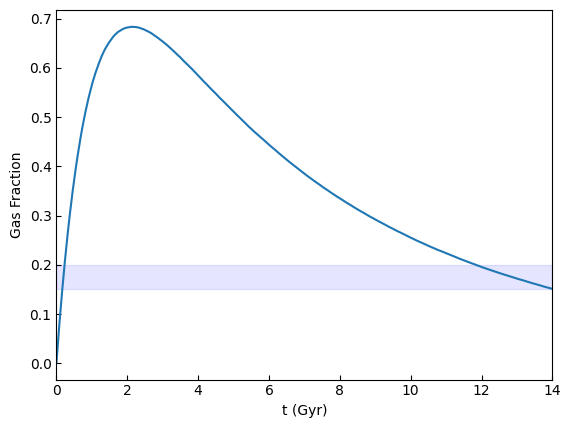

In [9]:
g = props[molecular_cloud]['zone mass'] + props[gas]['zone mass'] + props[old_dust]['zone mass']

plt.plot(props[molecular_cloud]['time'] / 3.15e16, g / 1.e6)

plt.xlabel('t (Gyr)')
plt.ylabel('Gas Fraction')

plt.tick_params(direction="in")
plt.xlim([0, 14])

plt.fill_between([0,14], [0.15, 0.15], [0.2, 0.2], color='blue', alpha=0.1)

if save_figs:
    plt.savefig('gas_frac.pdf')

plt.show()

Now plot the masses in the various dust reservoirs relative to the total mass in gas and dust.  Correct the dust mass by the metallicity to account for the mass in condensible elements.

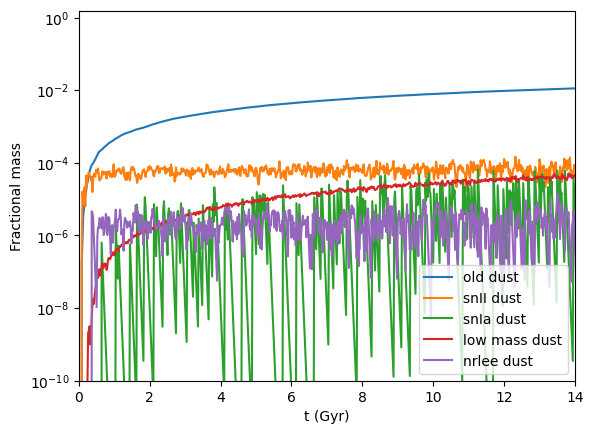

In [10]:
full_mass = props[gas]['zone mass'] + props[molecular_cloud]['zone mass'] + props[old_dust]['zone mass']

dust_comps = {old_dust: 'old dust', snII_dust: 'snII dust', snIa_dust: 'snIa dust', low_mass_dust: 'low mass dust', nrlee_dust: 'nrlee dust'}

dust_mass = {}
for component in dust_comps:
    dust_mass[component] = props[component]['zone mass'] * props[component]['metallicity']
    plt.plot(props[component]['time'] / 3.15e16, dust_mass[component] / full_mass, label = dust_comps[component])

plt.yscale('log')
plt.ylim([1.e-10,1.5])
plt.xlim([0,14])

plt.xlabel('t (Gyr)')
plt.ylabel('Fractional mass')

plt.legend()

if save_figs:
    plt.savefig('dust_mass.pdf')

Now plot the metallicity as a function of time in the model.  The model reaches solar metallicity (about 0.02 in the Anders and Grevesse compilation) around 8 Gyr into the Galactic evolution in the model.

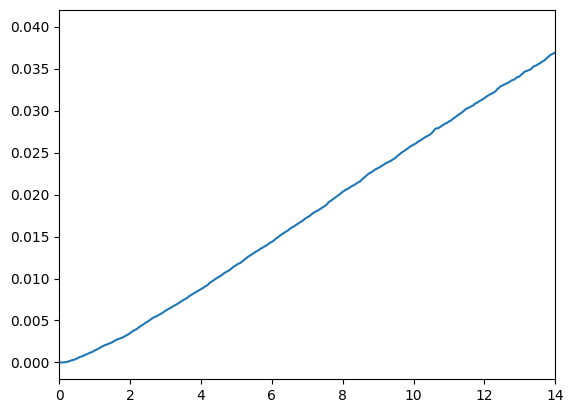

In [11]:
plt.plot(props[gas]['time'] / 3.15e16, props[gas]['metallicity'])
plt.xlim([0,14])
plt.show()

Plot the mass fraction of key species in the Molecular Cloud phase relative to their Solar abundances.  Key species are close to their Solar abundances at the time of the Sun's formation (at around 8 Gyr in the model).

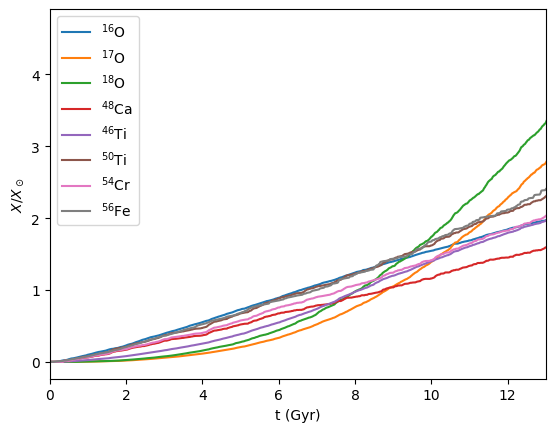

In [12]:
species = ['o16', 'o17', 'o18', 'ca48', 'ti46', 'ti50', 'cr54', 'fe56']

l_s = h5.get_latex_names(species)

x = h5.get_zone_mass_fractions_in_groups(molecular_cloud, species)

for s in species:
    tup = solar_xml.get_z_a_state_from_nuclide_name(s)
    s_tup=(s, tup[0], tup[1])
    plt.plot(props[molecular_cloud]['time'] / 3.15e16, x[s] / x_solar[s_tup], label = l_s[s])

plt.xlabel('t (Gyr)')
plt.ylabel('$X / X_\\odot$')

plt.xlim([0,13])

plt.legend()

if save_figs:
    plt.savefig('mass_fracs_vs_time.pdf')
    
plt.show()

Find the time of the Sun's birth.  The default is to take the first timestep in the model after 7.999 Gyr.

In [13]:
i = []
for j in range(len(props[molecular_cloud]['time'])):
    if props[molecular_cloud]['time'][j] / 3.15e16 > 7.999:
        i.append(j)

Now graph the abundances in the model at Solar System formation relative to the actual Solar System abundances.  Isotopes of the same element are connected with a line of the same color.  A perfect model would have the ratio equal to one for all species.  The model manages to fit most species within a factor of two of the Solar abundance at 8 Gyr.

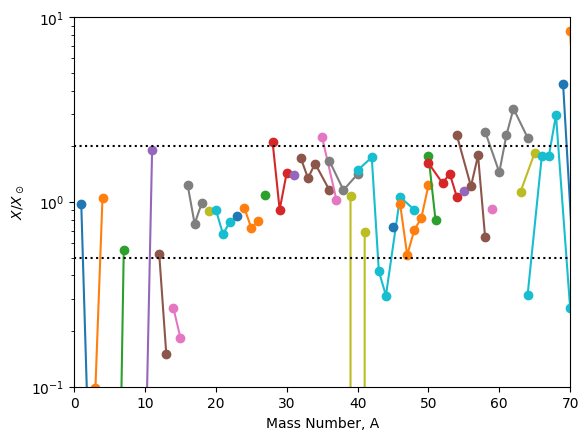

In [18]:
nucs = h5.get_nuclide_data()
species = []

for m in x_solar:
    if m[0] in nucs:
        species.append(m[0])

x = h5.get_zone_mass_fractions_in_groups(molecular_cloud, species)

a_dict = {}
x_dict = {}

for sp in species:
    tup = solar_xml.get_z_a_state_from_nuclide_name(sp)
    if tup[0] in a_dict:
        a_dict[tup[0]].append(tup[1])
        x_dict[tup[0]].append(x[sp][i[0]] / x_solar[(sp, tup[0], tup[1])])
    else:
        a_dict[tup[0]] = [tup[1]]
        x_dict[tup[0]] = [x[sp][i[0]] / x_solar[(sp, tup[0], tup[1])]]
        
for z in a_dict:
    plt.plot(a_dict[z], x_dict[z], 'o-')

plt.plot([0,100], [2, 2], ':', color = 'black')
plt.plot([0,100], [0.5, 0.5], ':', color = 'black')

plt.yscale('log')
plt.xlim([0, 70])
plt.ylim([0.1, 10])

plt.xlabel('Mass Number, A')
plt.ylabel('$X / X_\\odot$')

if save_figs:
    plt.savefig('mass_fracs_at_solar.pdf')

plt.show()

In [19]:
x = {}

for component in [molecular_cloud, gas, old_dust, snII_dust, snIa_dust, low_mass_dust]:
    x[component] = h5.get_zone_mass_fractions_in_groups(component, species)
    
delta_17 = {}
delta_18 = {}

for component in x:
    delta_17[component] = 1000 * ((x[component]['o17'][i[0]]/x[component]['o16'][i[0]])/(x[molecular_cloud]['o17'][i[0]]/x[molecular_cloud]['o16'][i[0]]) - 1)
    delta_18[component] = 1000 * ((x[component]['o18'][i[0]]/x[component]['o16'][i[0]])/(x[molecular_cloud]['o18'][i[0]]/x[molecular_cloud]['o16'][i[0]]) - 1)

for component in x:
    print(component[0], delta_17[component], delta_18[component])

molecular cloud 0.0 0.0
gas -3.844080109981829 -4.031994450312548
old_dust -4.231353907010682 -4.4382124222667185
snII_dust 1705.7011968815705 1626.7981670534791
snIa_dust -999.849352859045 -999.9991644441532
low_mass_dust -252.45390801470347 -244.19323197199992


In [20]:
m16 = 0
m17 = 0
m18 = 0

total_dust_mass = 1.e-300

for component in [old_dust, snII_dust, snIa_dust, low_mass_dust]:
    m16 += x[component]['o16'] * dust_mass[component]
    m17 += x[component]['o17'] * dust_mass[component]
    m18 += x[component]['o18'] * dust_mass[component]
    total_dust_mass += dust_mass[component]
        
m16 /= total_dust_mass
m17 /= total_dust_mass
m18 /= total_dust_mass
                            
d17 = 1000 * ((m17[i[0]]/x[molecular_cloud]['o17'][i[0]])/(m16[i[0]]/x[molecular_cloud]['o16'][i[0]]) - 1)
d18 = 1000 * ((m18[i[0]]/x[molecular_cloud]['o18'][i[0]])/(m16[i[0]]/x[molecular_cloud]['o16'][i[0]]) - 1)

print(d17, d18)

70.86631277032174 67.12805852942982


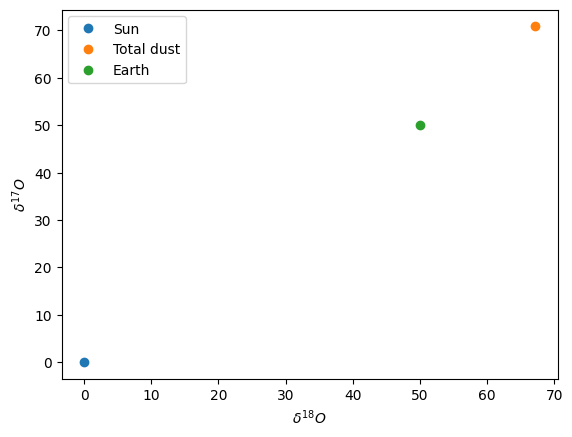

In [21]:
plt.plot(0, 0, 'o', label='Sun')
plt.plot(d18, d17, 'o', label='Total dust')
plt.plot(50, 50, 'o', label='Earth')
plt.xlabel('$\\delta ^{18}O$')
plt.ylabel('$\\delta ^{17}O$')
plt.legend()

plt.show()

In [39]:
species = ['ca40', 'ca48', 'ti47', 'ti50', 'cr52', 'cr54']
x_mc = h5.get_zone_mass_fractions_in_groups(molecular_cloud, species)
x_nrlee = h5.get_zone_mass_fractions_in_groups(nrlee_dust, species)



In [46]:
y_mc = {}
print('In Molecular Cloud')
for sp in species:
    print(sp, '{:.2e}'.format(x_mc[sp][i[0]]))
    y_mc[sp] = x_mc[sp][i[0]]

In Molecular Cloud
ca40 8.88e-05
ca48 1.26e-07
ti47 1.07e-07
ti50 2.02e-07
cr52 1.88e-05
cr54 4.65e-07


In [47]:
y_nrlee = {}
print('In NRLEE')
for sp in species:
    print(sp, '{:.2e}'.format(x_nrlee[sp][i[0]]))
    y_nrlee[sp] = x_nrlee[sp][i[0]]

In NRLEE
ca40 2.28e-02
ca48 1.66e-04
ti47 1.97e-06
ti50 2.41e-04
cr52 4.19e-03
cr54 5.33e-04


In [48]:
print('In NRLEE/MC')
for sp in species:
    print(sp, '{:.2e}'.format(x_nrlee[sp][i[0]]/x_mc[sp][i[0]]))

In NRLEE/MC
ca40 2.57e+02
ca48 1.32e+03
ti47 1.84e+01
ti50 1.19e+03
cr52 2.23e+02
cr54 1.15e+03


In [49]:
y_nnr = {}
f = 1.e-4
for sp in species:
    print(sp, (100. * x_mc[sp][i[0]] - f * x_nrlee[sp][i[0]])/(1-f))
    y_nnr[sp] = (100. * x_mc[sp][i[0]] - f * x_nrlee[sp][i[0]])/(1-f)

ca40 0.008879309954027104
ca48 1.253758329119309e-05
ti47 1.0736766885998547e-05
ti50 2.0212559700747506e-05
cr52 0.0018766652196380944
cr54 4.641415902668041e-05


In [61]:
f = 2.e-4
for sp in species:
    r = (0.1 * f * y_nrlee[sp] + 0.2 * (1-f) * y_nnr[sp])/y_mc[sp]
    print(sp,r)

ca40 19.998000314300562
ca48 19.998002438491767
ti47 19.99799983676739
ti50 19.998002186624642
cr52 19.99800024626049
cr54 19.998002096095494
